In [1]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [2]:
import os
os.listdir(); os.chdir("/home/azm0269@auburn.edu/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()


# DDPO: denoising diffusion policy optimization

This notebook implements DDPO-style policy optimization for a text-to-image diffusion model. The denoising process is treated as a trajectory, each denoising transition receives a policy log probability, and a black-box terminal image reward is optimized with a PPO clipped objective.

The default reward below is intentionally lightweight so the notebook runs without a separate reward model. Replace `reward_fn` with an aesthetic, CLIP, ImageReward, human preference, or task-specific scorer when you are ready to train against a real objective.


In [3]:
from __future__ import annotations

import gc
import math
import random
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Callable

import numpy as np
import torch
import torch.nn.functional as F
from diffusers import DDPMScheduler, StableDiffusionPipeline
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image
from torch import Tensor
from tqdm.auto import trange


In [4]:
@dataclass
class DDPOConfig:
    model_id: str = "runwayml/stable-diffusion-v1-5"
    output_dir: str = "outputs/ddpo"
    seed: int = 17
    gpu_ids: list[int] = field(default_factory=lambda: [0, 1, 2])
    use_data_parallel: bool = False

    prompt: str = "a colorful clover field at sunrise, high detail"
    negative_prompt: str = "blurry, low quality, distorted"
    train_prompts: tuple[str, ...] = (
        "a colorful clover field at sunrise, high detail",
        "a close-up photo of a bright green clover leaf with dew",
        "a small robot holding a clover in a clean studio photo",
        "an impressionist painting of clovers under warm sunlight",
    )

    height: int = 512
    width: int = 512
    num_inference_steps: int = 30
    guidance_scale: float = 7.5
    eta: float = 1.0

    rollouts_per_epoch: int = 1
    train_epochs: int = 4
    ppo_epochs: int = 4
    minibatch_size: int = 1
    learning_rate: float = 1e-9
    adam_epsilon: float = 1e-4
    lora_rank: int = 2
    lora_alpha: int = 2
    lora_dropout: float = 0.0
    lora_target_modules: tuple[str, ...] = ("to_v",)
    clip_range: float = 1e-4
    ppo_log_ratio_clip: float = 2.0
    max_grad_norm: float = 0.1
    mixed_precision: bool = True
    gradient_checkpointing: bool = True

    log_every: int = 1
    save_every: int = 5


cfg = DDPOConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
cfg


DDPOConfig(model_id='runwayml/stable-diffusion-v1-5', output_dir='outputs/ddpo', seed=17, gpu_ids=[0, 1, 2], use_data_parallel=False, prompt='a colorful clover field at sunrise, high detail', negative_prompt='blurry, low quality, distorted', train_prompts=('a colorful clover field at sunrise, high detail', 'a close-up photo of a bright green clover leaf with dew', 'a small robot holding a clover in a clean studio photo', 'an impressionist painting of clovers under warm sunlight'), height=512, width=512, num_inference_steps=30, guidance_scale=7.5, eta=1.0, rollouts_per_epoch=1, train_epochs=4, ppo_epochs=4, minibatch_size=1, learning_rate=1e-09, adam_epsilon=0.0001, lora_rank=2, lora_alpha=2, lora_dropout=0.0, lora_target_modules=('to_v',), clip_range=0.0001, ppo_log_ratio_clip=2.0, max_grad_norm=0.1, mixed_precision=True, gradient_checkpointing=True, log_every=1, save_every=5)

In [5]:
def resolve_gpu_ids(config: DDPOConfig) -> list[int]:
    if not torch.cuda.is_available():
        return []
    visible_count = torch.cuda.device_count()
    return [gpu_id for gpu_id in config.gpu_ids if 0 <= gpu_id < visible_count]


gpu_ids = resolve_gpu_ids(cfg)
device = torch.device(f"cuda:{gpu_ids[0]}" if gpu_ids else "cpu")
dtype = torch.float16 if device.type == "cuda" and cfg.mixed_precision else torch.float32


def set_seed(seed: int) -> torch.Generator:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    generator_device = device.type if device.type == "cpu" else str(device)
    return torch.Generator(device=generator_device).manual_seed(seed)


generator = set_seed(cfg.seed)
print(device, dtype, f"gpu_ids={gpu_ids}")


cuda:0 torch.float16 gpu_ids=[0, 1, 2]


In [6]:
@torch.no_grad()
def aesthetic_proxy_reward(images: list[Image.Image], prompts: list[str]) -> Tensor:
    """Small offline reward used as a placeholder for a real preference model.

    It rewards images that are bright, saturated, and have moderate contrast. DDPO only
    needs terminal scalar rewards, so any black-box scorer with this signature can be
    swapped in here.
    """
    rewards = []
    for image in images:
        arr = torch.from_numpy(np.asarray(image).astype("float32") / 255.0)
        mean_rgb = arr.mean(dim=(0, 1))
        brightness = arr.mean()
        saturation = (mean_rgb.max() - mean_rgb.min()).clamp_min(0.0)
        contrast = arr.std().clamp_max(0.35)
        rewards.append(0.45 * brightness + 0.35 * saturation + 0.20 * contrast)
    return torch.stack(rewards).to(device)


reward_fn: Callable[[list[Image.Image], list[str]], Tensor] = aesthetic_proxy_reward


In [7]:
def unwrap_unet(unet: torch.nn.Module) -> torch.nn.Module:
    return unet.module if isinstance(unet, torch.nn.DataParallel) else unet


def unet_config(pipe: StableDiffusionPipeline):
    return unwrap_unet(pipe.unet).config


def trainable_parameters(module: torch.nn.Module) -> list[torch.nn.Parameter]:
    return [parameter for parameter in module.parameters() if parameter.requires_grad]


def save_lora_weights(pipe: StableDiffusionPipeline, save_dir: Path | str) -> None:
    unet = unwrap_unet(pipe.unet)
    pipe.save_lora_weights(
        save_directory=save_dir,
        unet_lora_layers=get_peft_model_state_dict(unet),
        safe_serialization=True,
    )


def load_pipeline(config: DDPOConfig) -> StableDiffusionPipeline:
    pipe = StableDiffusionPipeline.from_pretrained(
        config.model_id,
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
    pipe.scheduler = DDPMScheduler.from_config(pipe.scheduler.config, clip_sample=False)
    pipe.scheduler.register_to_config(clip_sample=False)
    pipe = pipe.to(device)

    pipe.vae.requires_grad_(False)
    pipe.text_encoder.requires_grad_(False)
    pipe.unet.requires_grad_(False)
    lora_config = LoraConfig(
        r=config.lora_rank,
        lora_alpha=config.lora_alpha,
        lora_dropout=config.lora_dropout,
        init_lora_weights="gaussian",
        target_modules=list(config.lora_target_modules),
    )
    pipe.unet.add_adapter(lora_config)
    pipe.unet.train()

    if config.gradient_checkpointing and hasattr(pipe.unet, "enable_gradient_checkpointing"):
        pipe.unet.enable_gradient_checkpointing()

    try:
        pipe.enable_xformers_memory_efficient_attention()
        print("xFormers memory efficient attention enabled")
    except Exception as exc:
        print(f"xFormers not enabled: {exc}")

    if config.use_data_parallel and len(gpu_ids) > 1:
        pipe.unet = torch.nn.DataParallel(pipe.unet, device_ids=gpu_ids, output_device=gpu_ids[0])
        print(f"UNet wrapped with DataParallel on GPUs {gpu_ids}")

    return pipe


pipe = load_pipeline(cfg)
lora_parameters = trainable_parameters(pipe.unet)
print(f"Training {sum(parameter.numel() for parameter in lora_parameters):,} LoRA parameters")
optimizer = torch.optim.AdamW(lora_parameters, lr=cfg.learning_rate, eps=cfg.adam_epsilon)
vae_scale_factor = 2 ** (len(pipe.vae.config.block_out_channels) - 1)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

xFormers memory efficient attention enabled
Training 99,456 LoRA parameters


In [8]:
def encode_prompts(pipe: StableDiffusionPipeline, prompts: list[str], negative_prompt: str) -> Tensor:
    tokenized = pipe.tokenizer(
        prompts,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    negative = pipe.tokenizer(
        [negative_prompt] * len(prompts),
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    with torch.no_grad():
        text_embeds = pipe.text_encoder(tokenized.input_ids.to(device))[0]
        negative_embeds = pipe.text_encoder(negative.input_ids.to(device))[0]
    return torch.cat([negative_embeds, text_embeds], dim=0).to(dtype=dtype)


def predict_noise(pipe: StableDiffusionPipeline, latents: Tensor, timestep: Tensor | int, prompt_embeds: Tensor) -> Tensor:
    latent_model_input = torch.cat([latents, latents], dim=0)
    if isinstance(pipe.unet, torch.nn.DataParallel):
        timestep = torch.as_tensor(timestep, device=latents.device).expand(latent_model_input.shape[0])
    noise_pred = pipe.unet(latent_model_input, timestep, encoder_hidden_states=prompt_embeds, return_dict=False)[0]
    if not torch.isfinite(noise_pred).all():
        raise FloatingPointError("UNet predicted non-finite noise; skip this update or lower the learning rate.")
    noise_uncond, noise_text = noise_pred.chunk(2)
    guided_noise = noise_uncond + cfg.guidance_scale * (noise_text - noise_uncond)
    if not torch.isfinite(guided_noise).all():
        raise FloatingPointError("Classifier-free guidance produced non-finite noise; lower guidance_scale or learning_rate.")
    return guided_noise


def decode_latents(pipe: StableDiffusionPipeline, latents: Tensor) -> list[Image.Image]:
    if not torch.isfinite(latents).all():
        raise FloatingPointError("Cannot decode non-finite latents; the rollout/update became unstable.")
    latents = latents / pipe.vae.config.scaling_factor
    with torch.no_grad():
        images = pipe.vae.decode(latents.to(dtype=pipe.vae.dtype)).sample
    if not torch.isfinite(images).all():
        raise FloatingPointError("VAE decoded non-finite images; the latents are unstable.")
    images = (images / 2 + 0.5).clamp(0, 1)
    images = images.detach().cpu().permute(0, 2, 3, 1).float().numpy()
    images = (images * 255).round().astype("uint8")
    return [Image.fromarray(image) for image in images]


In [9]:
def previous_timestep(scheduler: DDPMScheduler, timestep: int) -> int:
    if hasattr(scheduler, "previous_timestep"):
        prev = scheduler.previous_timestep(timestep)
        return int(prev.item() if torch.is_tensor(prev) else prev)
    step = scheduler.config.num_train_timesteps // scheduler.num_inference_steps
    return int(timestep) - step


def ddpm_mean_std(scheduler: DDPMScheduler, model_output: Tensor, timestep: int, sample: Tensor) -> tuple[Tensor, Tensor]:
    """Mean and std of p_theta(x_{t-1} | x_t) for fixed-variance DDPM transitions."""
    if model_output.shape[1] == sample.shape[1] * 2:
        model_output, _ = torch.split(model_output, sample.shape[1], dim=1)

    sample_float = sample.float()
    if not torch.isfinite(sample_float).all():
        raise FloatingPointError("Non-finite DDPM sample; skip this update or lower the learning rate.")
    model_output = model_output.float()
    if not torch.isfinite(model_output).all():
        raise FloatingPointError("Non-finite DDPM model output; skip this update or lower the learning rate.")
    t = int(timestep)
    prev_t = previous_timestep(scheduler, t)
    alphas_cumprod = scheduler.alphas_cumprod.to(device=sample.device, dtype=torch.float32)
    alpha_prod_t = alphas_cumprod[t]
    if prev_t >= 0:
        alpha_prod_t_prev = alphas_cumprod[prev_t]
    elif hasattr(scheduler, "final_alpha_cumprod"):
        alpha_prod_t_prev = scheduler.final_alpha_cumprod.to(device=sample.device, dtype=torch.float32)
    elif hasattr(scheduler, "one"):
        alpha_prod_t_prev = scheduler.one.to(device=sample.device, dtype=torch.float32)
    else:
        alpha_prod_t_prev = torch.ones((), device=sample.device, dtype=torch.float32)
    beta_prod_t = 1 - alpha_prod_t
    beta_prod_t_prev = 1 - alpha_prod_t_prev

    prediction_type = getattr(scheduler.config, "prediction_type", "epsilon")
    if prediction_type == "epsilon":
        pred_original_sample = (sample_float - beta_prod_t.sqrt() * model_output) / alpha_prod_t.sqrt()
    elif prediction_type == "sample":
        pred_original_sample = model_output
    elif prediction_type == "v_prediction":
        pred_original_sample = alpha_prod_t.sqrt() * sample_float - beta_prod_t.sqrt() * model_output
    else:
        raise ValueError(f"Unsupported prediction type: {prediction_type}")

    if scheduler.config.clip_sample:
        clip_range = getattr(scheduler.config, "clip_sample_range", 1.0)
        pred_original_sample = pred_original_sample.clamp(-clip_range, clip_range)

    current_alpha_t = alpha_prod_t / alpha_prod_t_prev
    current_beta_t = 1 - current_alpha_t
    pred_original_sample_coeff = alpha_prod_t_prev.sqrt() * current_beta_t / beta_prod_t
    current_sample_coeff = current_alpha_t.sqrt() * beta_prod_t_prev / beta_prod_t
    mean = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample_float

    if not torch.isfinite(mean).all():
        raise FloatingPointError("Non-finite DDPM transition mean; reduce LR/clip range or disable mixed precision.")

    variance = (beta_prod_t_prev / beta_prod_t) * current_beta_t
    variance = variance.clamp(min=1e-12)
    std = (cfg.eta * variance.sqrt()).clamp_min(1e-6)
    if not torch.isfinite(std).all():
        raise FloatingPointError("Non-finite DDPM transition std; reduce LR/clip range or disable mixed precision.")
    return mean, std


def transition_log_prob(mean: Tensor, std: Tensor, prev_sample: Tensor) -> Tensor:
    prev_sample = prev_sample.float()
    mean = mean.float()
    std = std.float().clamp_min(1e-6)
    log_prob = -0.5 * ((prev_sample - mean) / std).pow(2) - torch.log(std) - 0.5 * math.log(2 * math.pi)
    if not torch.isfinite(log_prob).all():
        raise FloatingPointError("Non-finite transition log-prob; reduce LR/clip range or disable mixed precision.")
    return log_prob.flatten(1).mean(dim=1)


def ddpm_step_with_log_prob(
    scheduler: DDPMScheduler,
    model_output: Tensor,
    timestep: int,
    sample: Tensor,
    generator: torch.Generator | None = None,
    prev_sample: Tensor | None = None,
) -> tuple[Tensor, Tensor]:
    mean, std = ddpm_mean_std(scheduler, model_output, timestep, sample)
    if prev_sample is None:
        noise = torch.randn(sample.shape, generator=generator, device=sample.device, dtype=torch.float32)
        prev_sample = (mean + std * noise).to(sample.dtype)
    log_prob = transition_log_prob(mean, std, prev_sample)
    return prev_sample, log_prob


In [10]:
def sample_prompt_batch(batch_size: int) -> list[str]:
    return [random.choice(cfg.train_prompts) for _ in range(batch_size)]


@torch.no_grad()
def collect_rollouts(pipe: StableDiffusionPipeline, batch_size: int) -> dict[str, Tensor | list[str] | list[Image.Image]]:
    pipe.unet.eval()
    prompts = sample_prompt_batch(batch_size)
    prompt_embeds = encode_prompts(pipe, prompts, cfg.negative_prompt)
    pipe.scheduler.set_timesteps(cfg.num_inference_steps, device=device)

    latent_shape = (
        batch_size,
        unet_config(pipe).in_channels,
        cfg.height // vae_scale_factor,
        cfg.width // vae_scale_factor,
    )
    latents = torch.randn(latent_shape, generator=generator, device=device, dtype=dtype)
    latents = latents * pipe.scheduler.init_noise_sigma

    states, actions, log_probs, timesteps, rewards = [], [], [], [], []
    images = []
    zero_rewards = torch.zeros(batch_size, dtype=torch.float32)
    for t in pipe.scheduler.timesteps:
        timestep = int(t.item())
        states.append(latents.detach().float().cpu())
        noise_pred = predict_noise(pipe, latents, t, prompt_embeds)
        next_latents, log_prob = ddpm_step_with_log_prob(pipe.scheduler, noise_pred, timestep, latents, generator)
        actions.append(next_latents.detach().float().cpu())
        log_probs.append(log_prob.detach().float().cpu())
        timesteps.append(timestep)
        latents = next_latents
        if timestep == 0:
            images = decode_latents(pipe, latents)
            rewards.append(reward_fn(images, prompts).detach().float().cpu())
        else:
            rewards.append(zero_rewards.clone())

    if not images:
        images = decode_latents(pipe, latents)
    pipe.unet.train()

    return {
        "prompts": prompts,
        "states": torch.stack(states, dim=1),
        "actions": torch.stack(actions, dim=1),
        "old_log_probs": torch.stack(log_probs, dim=1),
        "timesteps": torch.tensor(timesteps, dtype=torch.long),
        "rewards": torch.stack(rewards, dim=1),
        "images": images,
    }


In [11]:
def normalize_advantages(rewards: Tensor) -> Tensor:
    advantages = rewards - rewards.mean()
    if rewards.numel() > 1:
        advantages = advantages / (rewards.std(unbiased=False) + 1e-8)
    return advantages


def finite_trainable_parameters(module: torch.nn.Module) -> bool:
    return all(torch.isfinite(parameter).all().item() for parameter in trainable_parameters(module))


def clone_trainable_parameters(module: torch.nn.Module) -> list[Tensor]:
    return [parameter.detach().clone() for parameter in trainable_parameters(module)]


def restore_trainable_parameters(module: torch.nn.Module, snapshot: list[Tensor]) -> None:
    with torch.no_grad():
        for parameter, saved in zip(trainable_parameters(module), snapshot):
            parameter.copy_(saved)


def clear_optimizer_state(optimizer: torch.optim.Optimizer) -> None:
    optimizer.state.clear()


def safe_metric_mean(values: list[float]) -> float:
    return float(np.mean(values)) if values else float("nan")


def ppo_update(pipe: StableDiffusionPipeline, rollout: dict[str, Tensor | list[str]], optimizer: torch.optim.Optimizer) -> dict[str, float]:
    states = rollout["states"]
    actions = rollout["actions"]
    old_log_probs = rollout["old_log_probs"]
    timesteps = rollout["timesteps"].tolist()
    rewards = rollout["rewards"]
    prompts = rollout["prompts"]
    advantages = normalize_advantages(rewards).to(device)

    batch_size, trajectory_len = old_log_probs.shape
    indices = torch.arange(batch_size)
    losses, approx_kls, clip_fracs = [], [], []
    skipped_updates = 0

    pipe.unet.train()
    if not finite_trainable_parameters(pipe.unet):
        raise FloatingPointError("LoRA parameters are already non-finite; reload the pipeline cell before continuing.")

    for _ in range(cfg.ppo_epochs):
        permutation = indices[torch.randperm(batch_size)]
        for start in range(0, batch_size, cfg.minibatch_size):
            mb_idx = permutation[start:start + cfg.minibatch_size]
            mb_prompts = [prompts[i] for i in mb_idx.tolist()]
            prompt_embeds = encode_prompts(pipe, mb_prompts, cfg.negative_prompt)
            mb_advantages = advantages[mb_idx]
            parameter_snapshot = clone_trainable_parameters(pipe.unet)

            optimizer.zero_grad(set_to_none=True)
            try:
                for step_idx, timestep in enumerate(timesteps):
                    t = torch.tensor(timestep, device=device, dtype=torch.long)
                    state = states[mb_idx, step_idx].to(device=device, dtype=dtype)
                    action = actions[mb_idx, step_idx].to(device=device, dtype=dtype)
                    noise_pred = predict_noise(pipe, state, t, prompt_embeds)
                    _, log_prob = ddpm_step_with_log_prob(pipe.scheduler, noise_pred, timestep, state, prev_sample=action)

                    old = old_log_probs[mb_idx, step_idx].to(device=device, dtype=log_prob.dtype)
                    if mb_advantages.ndim == 1:
                        adv = mb_advantages.to(device=device, dtype=log_prob.dtype)
                    else:
                        adv = mb_advantages[:, step_idx].to(device=device, dtype=log_prob.dtype)

                    log_ratio = log_prob - old
                    ratio = torch.exp(log_ratio.clamp(-cfg.ppo_log_ratio_clip, cfg.ppo_log_ratio_clip))
                    unclipped = ratio * adv
                    clipped = torch.clamp(ratio, 1 - cfg.clip_range, 1 + cfg.clip_range) * adv
                    step_loss = -torch.min(unclipped, clipped).mean() / trajectory_len
                    if not torch.isfinite(step_loss):
                        raise FloatingPointError("Non-finite PPO loss; skipped this minibatch update.")
                    step_loss.backward()

                    with torch.no_grad():
                        approx_kl = (old - log_prob).mean().abs()
                        clip_frac = ((ratio - 1).abs() > cfg.clip_range).float().mean()
                    losses.append(float((step_loss * trajectory_len).detach().cpu()))
                    approx_kls.append(float(approx_kl.detach().cpu()))
                    clip_fracs.append(float(clip_frac.detach().cpu()))

                    del state, action, noise_pred, log_prob, old, adv, log_ratio, ratio, unclipped, clipped, step_loss

                grad_norm = torch.nn.utils.clip_grad_norm_(trainable_parameters(pipe.unet), cfg.max_grad_norm)
                if not torch.isfinite(grad_norm):
                    raise FloatingPointError("Non-finite LoRA gradients; skipped this minibatch update.")

                optimizer.step()
                if not finite_trainable_parameters(pipe.unet):
                    restore_trainable_parameters(pipe.unet, parameter_snapshot)
                    clear_optimizer_state(optimizer)
                    raise FloatingPointError("AdamW produced non-finite LoRA parameters; restored previous weights and cleared optimizer state.")

            except FloatingPointError as exc:
                restore_trainable_parameters(pipe.unet, parameter_snapshot)
                optimizer.zero_grad(set_to_none=True)
                skipped_updates += 1
                print(f"Skipped PPO minibatch: {exc}")

            if device.type == "cuda":
                torch.cuda.empty_cache()

    return {
        "loss": safe_metric_mean(losses),
        "approx_kl": safe_metric_mean(approx_kls),
        "clip_frac": safe_metric_mean(clip_fracs),
        "reward_mean": float(rewards.mean()),
        "reward_std": float(rewards.std(unbiased=False)) if rewards.numel() > 1 else 0.0,
        "skipped_updates": skipped_updates,
    }


In [12]:
history = []
for epoch in trange(1, cfg.train_epochs + 1):
    rollout = collect_rollouts(pipe, cfg.rollouts_per_epoch)
    metrics = ppo_update(pipe, rollout, optimizer)
    metrics["epoch"] = epoch
    history.append(metrics)

    if epoch % cfg.log_every == 0:
        print(metrics)

    if epoch % cfg.save_every == 0:
        ckpt_dir = Path(cfg.output_dir) / f"lora_epoch_{epoch:04d}"
        save_lora_weights(pipe, ckpt_dir)
        for i, image in enumerate(rollout["images"]):
            image.save(Path(cfg.output_dir) / f"epoch_{epoch:04d}_sample_{i:02d}.png")

    del rollout
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()


  0%|          | 0/4 [00:00<?, ?it/s]

{'loss': 0.0, 'approx_kl': 0.0, 'clip_frac': 0.0, 'reward_mean': 0.0, 'reward_std': 0.0, 'skipped_updates': 0, 'epoch': 1}
{'loss': 0.0, 'approx_kl': 0.0, 'clip_frac': 0.0, 'reward_mean': 0.0, 'reward_std': 0.0, 'skipped_updates': 0, 'epoch': 2}
{'loss': 0.0, 'approx_kl': 0.0, 'clip_frac': 0.0, 'reward_mean': 0.0, 'reward_std': 0.0, 'skipped_updates': 0, 'epoch': 3}
{'loss': 0.0, 'approx_kl': 0.0, 'clip_frac': 0.0, 'reward_mean': 0.0, 'reward_std': 0.0, 'skipped_updates': 0, 'epoch': 4}


In [28]:
rollout = collect_rollouts(pipe, cfg.rollouts_per_epoch)

In [24]:
@torch.no_grad()
def generate_eval_images(pipe: StableDiffusionPipeline, prompts: list[str], seed: int = 123) -> list[Image.Image]:
    pipe.unet.eval()
    eval_generator = torch.Generator(device=device).manual_seed(seed)
    images = pipe(
        prompts,
        negative_prompt=[cfg.negative_prompt] * len(prompts),
        height=cfg.height,
        width=cfg.width,
        num_inference_steps=cfg.num_inference_steps,
        guidance_scale=cfg.guidance_scale,
        generator=eval_generator,
    ).images
    pipe.unet.train()
    return images


eval_prompts = [cfg.prompt, *cfg.train_prompts[:3]]
# eval_prompts = [
#     "a bottle of coca cola on a wooden table, high detail",
# ]
eval_images = generate_eval_images(pipe, eval_prompts)
for i, image in enumerate(eval_images):
    image.save(Path(cfg.output_dir) / f"eval_{i:02d}.png")

eval_images[0], eval_images[1], eval_images[2], eval_images[3]

  0%|          | 0/30 [00:00<?, ?it/s]

(<PIL.Image.Image image mode=RGB size=512x512>,
 <PIL.Image.Image image mode=RGB size=512x512>,
 <PIL.Image.Image image mode=RGB size=512x512>,
 <PIL.Image.Image image mode=RGB size=512x512>)

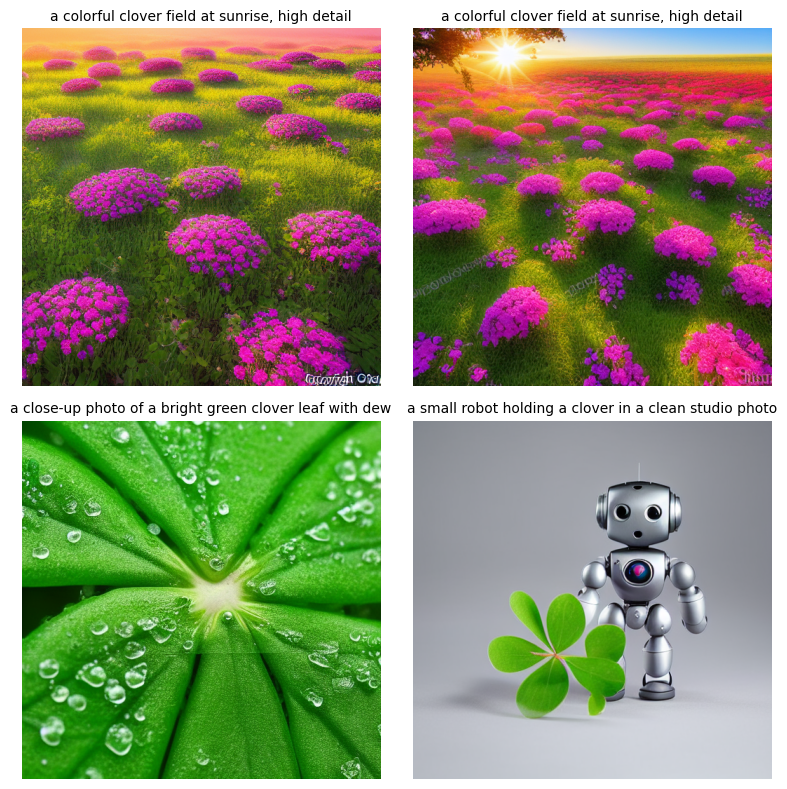

In [25]:
import matplotlib.pyplot as plt

images = eval_images
titles = eval_prompts

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img)
    ax.set_title(title, size=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
final_dir = Path(cfg.output_dir) / "lora_final"
save_lora_weights(pipe, final_dir)
print(f"Saved fine-tuned LoRA weights to {final_dir}")
print(asdict(cfg))
